<a href="https://colab.research.google.com/github/Nikralet/General/blob/main/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [421]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from typing import Literal

from matplotlib import cm
from scipy.linalg import eigh
from scipy.sparse import diags
from scipy import special
from scipy.special import gammaln

matplotlib.rcParams['animation.embed_limit'] = 50.0  # значение в мегабайтах

In [422]:
n = 50 # размер матриц, размер гильбертова пространства
N = 250
m = 1 # не трогать
h = 1 # не трогать
l = 6 # длина сетки
K = 2 # коэффициент связи между осцилляторами
omega1 = 1
omega2 = 3
omegas = tuple([omega1, omega2])
koeff = h/(2*m*40) # не трогать
a_birth = np.diag(np.array([np.sqrt(i) for i in range(1, n)]), k = -1)

a_destroy =np.diag(np.array([np.sqrt(i) for i in range(1, n)]), k = 1)

E = np.eye(n)

In [423]:
def hamilton_fock(linearity: Literal["linear", "nonlinear"], omega: float = 1.0):

  global a_birth, a_destroy, E, koeff, m, h

  x_sum = (a_destroy + a_birth)/np.sqrt(2 * omega)

  #x_razn = a_birth - a_destroy

  H_0 = h * omega * (a_birth @ a_destroy + 0.5 * E)

  if linearity == "linear":
    return H_0
  else:
    H_i = np.power(koeff/omega, 2) * (x_sum @ x_sum) @ (x_sum @ x_sum)
    return H_0 + H_i

In [424]:
def hamilton_fock_sviaz(linearity: Literal["linear", "nonlinear"], omegas: tuple = (1.0, 1.5)):
  global a_birth, a_destroy, E, koeff, m, h, K

  x_sum_1 = (a_destroy + a_birth)/np.sqrt(2 * omegas[0])
  x_sum_2 = (a_destroy + a_birth)/np.sqrt(2 * omegas[1])

  H = np.kron(hamilton_fock(linearity, omegas[0]), E) + np.kron(E, hamilton_fock(linearity, omegas[1])) + K *(m/np.sqrt(omegas[0]*omegas[1])) * np.kron(x_sum_1, x_sum_2)
  print('Обезразмеренный параметр связи')
  print('k/(m * sqrt(w1 * w2):', K *(m/np.sqrt(omegas[0]*omegas[1])))
  return H

In [425]:
def hermite_polynomial(n_, x):
    """Полиномы Эрмита"""
    return special.hermite(n_, monic=False)(x)
def harmonic_oscillator_wf(n_, x, m=1, omega=1):
    """
    Волновая функция гармонического осциллятора
    φ_n(x) = (1/√(π 2^n n!))^(1/2) * H_n(√(mω/ℏ)x) * exp(-mωx²/2ℏ)
    """
    # В атомных единицах ℏ = 1
    h_bar = 1
    alpha = np.sqrt(m * omega / h_bar)
    xi = alpha * x

    # Нормировочная константа (вычисляется безопасно)
    if n_ == 0:
        norm = (alpha / np.pi)**0.25
    else:
        # Для больших n используем логарифмы
        log_norm = -0.5 * (n_ * np.log(2) + gammaln(n_ + 1)) + 0.5 * np.log(alpha / np.sqrt(np.pi))
        norm = np.exp(log_norm)
    #norm = 1.0 / np.sqrt(2**n * special.factorial(n)) * (alpha / np.pi)**0.25
    # Волновая функция
    phi = norm * hermite_polynomial(n_, xi) * np.exp(-xi**2 / 2)

    return phi

In [426]:
def fock_to_coordinate_2d(psi_fock, omegas, x_grid):
    global n, m

    # Количество точек сетки
    nx = len(x_grid)
    n_states = psi_fock.shape[1]

    # Предвычисляем базисные функции для каждого осциллятора
    basis1 = np.zeros((nx, n))
    basis2 = np.zeros((nx, n))
    for ni in range(n):
        basis1[:, ni] = harmonic_oscillator_wf(ni, x_grid, m, omegas[0])
        basis2[:, ni] = harmonic_oscillator_wf(ni, x_grid, m, omegas[1])

    # Подготовим массив для результатов
    psi_coord = np.zeros((n_states, nx, nx), dtype=complex)

    for k in range(n_states):
        # Извлекаем коэффициенты для k-го состояния и преобразуем в матрицу n×n
        coeff = psi_fock[:, k].reshape((n, n), order='C')   # coeff[i, j] = c_{i,j}
        # Вычисляем волновую функцию на сетке: basis1 @ coeff @ basis2.T
        psi_coord[k] = basis1 @ coeff @ basis2.T

    dx = X_fock[1] - X_fock[0]
    print('Нормировка состояний')
    for i in range(min(3, Psi_fock_coordinate.shape[0])):
        norm = np.trapezoid(np.trapezoid(np.abs(Psi_fock_coordinate[i])**2, dx=dx, axis=1), dx=dx)
        print(f"Состояние {i}: ∫∫ |ψ|² dx1 dx2 = {norm:.2f}")

    return psi_coord

In [427]:
def solve_fok_basis(tasks):

  global a_birth, a_destroy, x_sum, x_razn, E, koeff, m, h, n, l, N

  h_fock = hamilton_fock_sviaz(linearity=tasks[0][1], omegas=tasks[0][0])

  # Диагонализация
  e_fock, psi_fock = eigh(h_fock)

  # Для визуализации создаем координатную сетку
  x_visual = np.linspace(-l, l, N)

  psi_fock_coordinate = fock_to_coordinate_2d(psi_fock=psi_fock, x_grid=x_visual, omegas=tasks[0][0])

  return e_fock, psi_fock_coordinate, x_visual

In [428]:
parameters = [(omegas, "linear")] # одно значение

E_fock, Psi_fock_coordinate, X_fock = solve_fok_basis(tasks=parameters)

Обезразмеренный параметр связи
k/(m * sqrt(w1 * w2): 1.1547005383792517
Нормировка состояний
Состояние 0: ∫∫ |ψ|² dx1 dx2 = 0.90
Состояние 1: ∫∫ |ψ|² dx1 dx2 = 0.77
Состояние 2: ∫∫ |ψ|² dx1 dx2 = 0.78


In [429]:
print("Первые 3 энергий:", E_fock[:3])

Первые 3 энергий: [1.97089759 2.88559317 3.80028875]


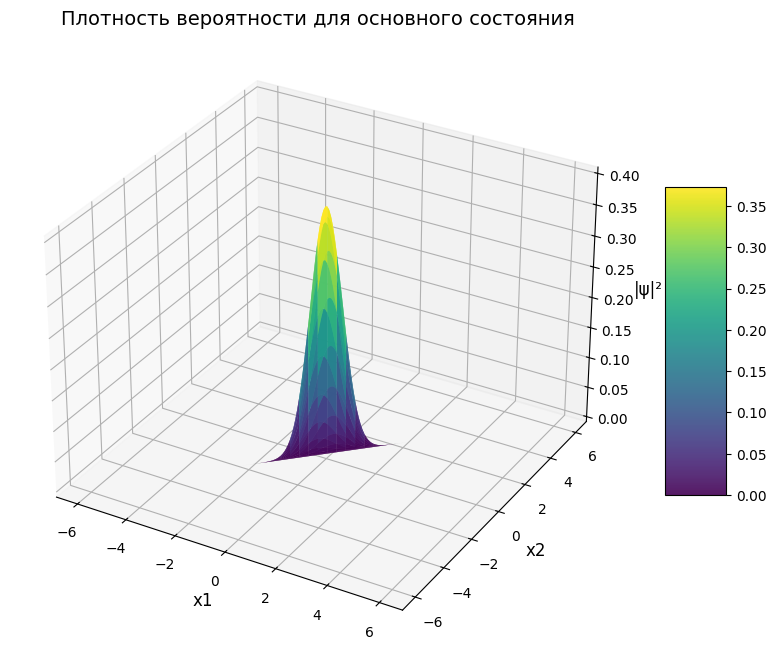

In [430]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X_fock, X_fock, np.abs(Psi_fock_coordinate[0])**2, cmap=cm.viridis, alpha=0.9, linewidth=0, antialiased=True)

# Настройка осей и меток
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_zlabel('|ψ|²', fontsize=12)
ax.set_title('Плотность вероятности для основного состояния', fontsize=14)

# Добавляем цветовую шкалу
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

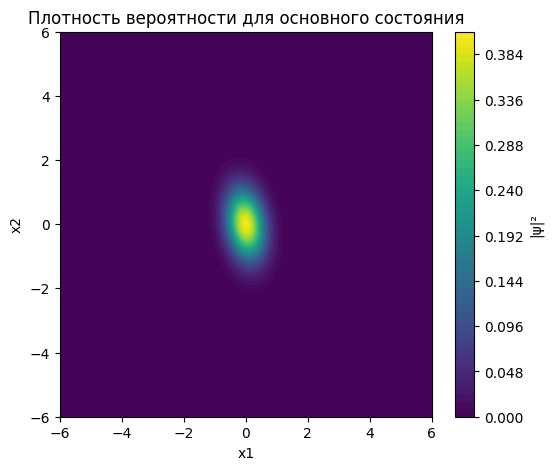

In [431]:
# Визуализация, например, для первого состояния
plt.figure(figsize=(6,5))
plt.contourf(X_fock, X_fock, np.abs(Psi_fock_coordinate[0])**2, levels=50, cmap='viridis')
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(label='|ψ|²')
plt.title('Плотность вероятности для основного состояния')
plt.show()